# MNIST Digit Classifier — ANN

A fully-connected Artificial Neural Network trained on MNIST. This is the baseline model in the `deep-learning-foundations` series — a dense network that treats each pixel independently, with no awareness of spatial structure. The CNN in `02-cnn-image-classifier` builds directly on this baseline to show what spatial learning actually adds.

**Dataset:** 60,000 training + 10,000 test images, 28×28 grayscale digits (0–9)  
**Target to beat:** 99%+ (CNN in next project)

## 1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Load & Preprocess Data

Pixel values scaled from 0–255 to 0–1 for stable training. Images kept as 28×28 — the `Flatten` layer inside the model handles reshaping.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Labels: {np.unique(y_train)}')

Train shape: (60000, 28, 28)
Test shape:  (10000, 28, 28)
Labels: [0 1 2 3 4 5 6 7 8 9]


### Sample images

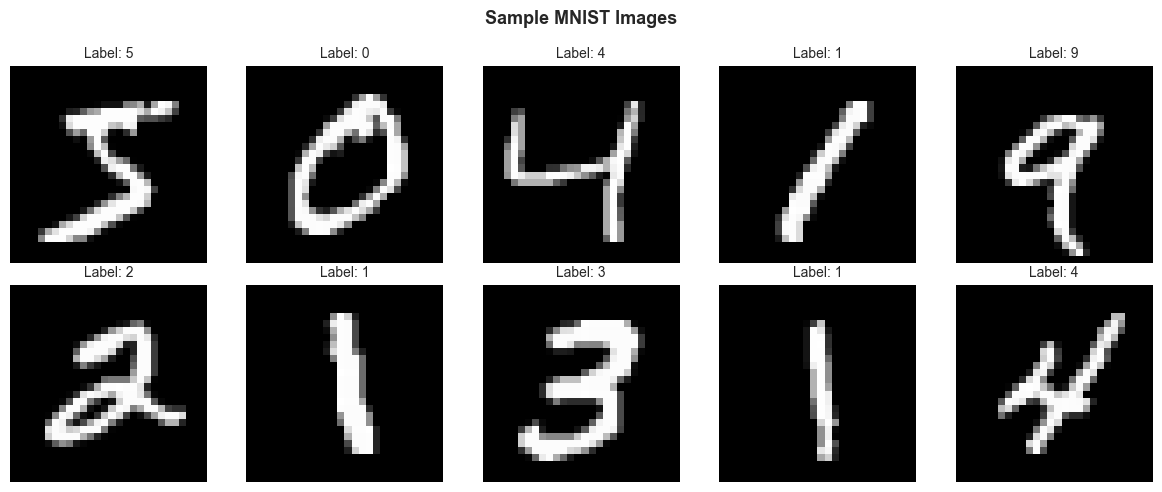

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Build the ANN

**Architecture:**

- `Flatten` — converts 28×28 image into a 784-length vector
- `Dense(128, ReLU)` — first hidden layer, learns feature combinations
- `Dropout(0.2)` — prevents overfitting by randomly disabling 20% of neurons
- `Dense(64, ReLU)` — second hidden layer, further abstraction
- `Dense(10, softmax)` — output layer, probability distribution over 10 classes

**Key limitation of ANN vs CNN:** the `Flatten` layer destroys all spatial information. A pixel in the top-left and a pixel in the bottom-right are treated as completely independent features — the network has no concept of neighboring pixels.

In [4]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64
)
print('Training complete.')

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8984 - loss: 0.3447 - val_accuracy: 0.9623 - val_loss: 0.1258
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9527 - loss: 0.1555 - val_accuracy: 0.9720 - val_loss: 0.0950
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9646 - loss: 0.1145 - val_accuracy: 0.9748 - val_loss: 0.0819
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9708 - loss: 0.0932 - val_accuracy: 0.9768 - val_loss: 0.0763
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9742 - loss: 0.0799 - val_accuracy: 0.9792 - val_loss: 0.0726
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9783 - loss: 0.0692 - val_accuracy: 0.9788 - val_loss: 0.0715
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9799 - loss: 0.0618 - val_accuracy: 0.9830 - val_loss: 0.0667
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9817 - loss: 0.0555 - val_accuracy: 0.

## 5. Training Curves

Train vs validation accuracy and loss per epoch — gap between them indicates overfitting.

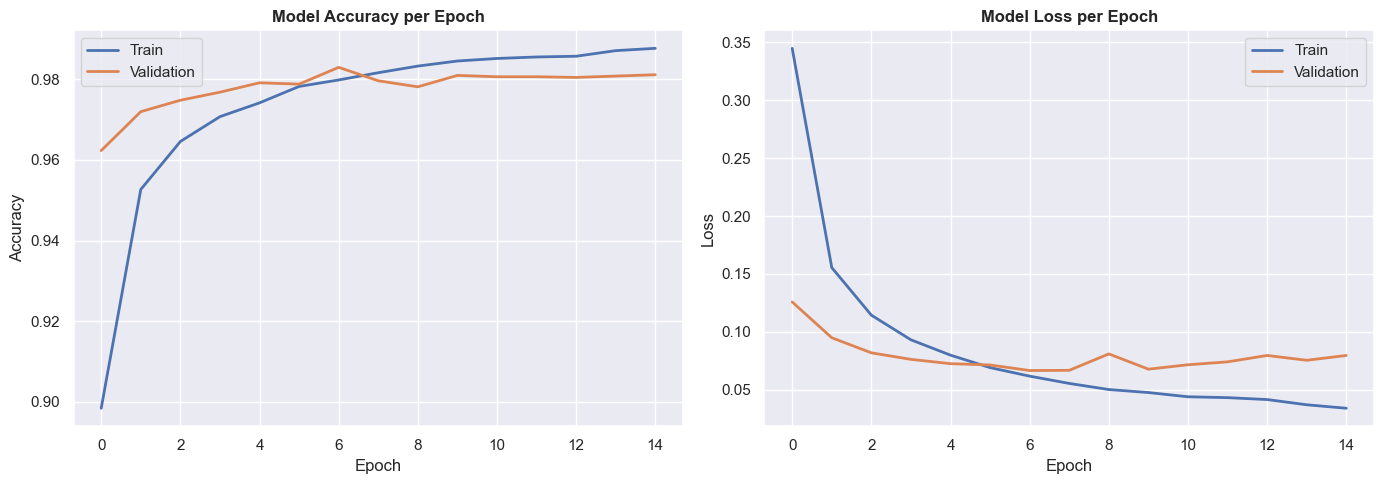

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluate on Test Set

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'ANN Test Accuracy: {test_acc:.4f}')
print(f'ANN Test Loss:     {test_loss:.4f}')

ANN Test Accuracy: 0.9791
ANN Test Loss:     0.0785


## 7. Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


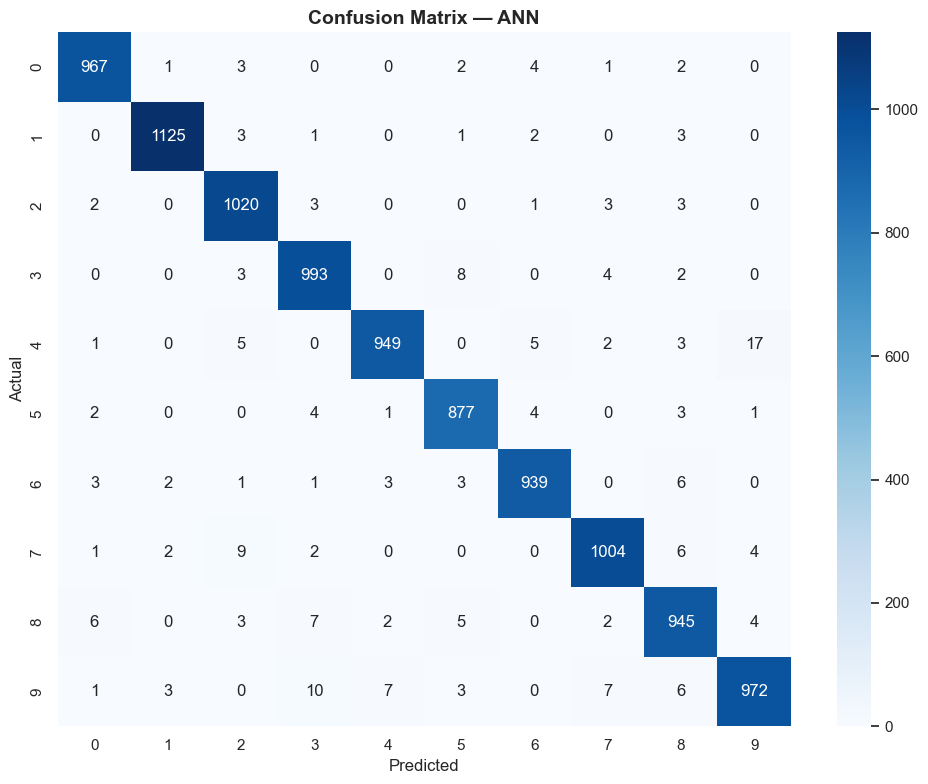

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [8]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — ANN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_labels))

## 8. Single Image Inference Demo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


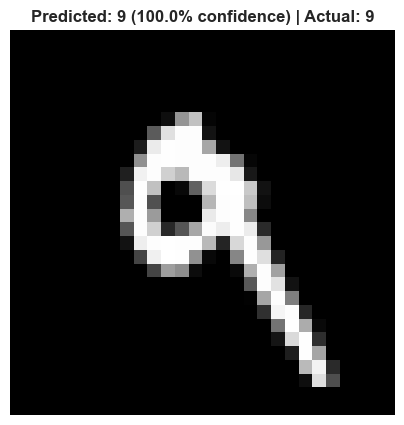

In [9]:
sample_index = 7
sample_image = X_test[sample_index]
true_label   = y_test[sample_index]

prediction      = model.predict(sample_image.reshape(1, 28, 28))
predicted_label = np.argmax(prediction)
confidence      = prediction[0][predicted_label] * 100

plt.imshow(sample_image, cmap='gray')
plt.title(f'Predicted: {predicted_label} ({confidence:.1f}% confidence) | Actual: {true_label}',
          fontweight='bold')
plt.axis('off')
plt.savefig('inference_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save the Model

In [10]:
model.save('ann_digit_classifier.keras')
print('Model saved to ann_digit_classifier.keras')

Model saved to ann_digit_classifier.keras


## 10. Results & What's Next

| Metric | Value |
|---|---|
| Test Accuracy | see output above |
| Architecture | Flatten → Dense(128) → Dropout → Dense(64) → Dense(10) |
| Epochs | 15 |
| Optimizer | Adam |

**Core limitation of this ANN:**  
Flattening the image loses all spatial structure. The network cannot learn that the top stroke of a '7' and the diagonal of a '1' are geometrically different — it only learns which pixel values correlate with which labels.

**Next:** `02-cnn-image-classifier` — convolutional layers scan the image with small filters that preserve spatial relationships, learning *where* patterns are, not just *whether* they exist. Same dataset, same task — measurably better results.